<div align="center">
<h1><a href="https://github.com/peremartra/Large-Language-Model-Notebooks-Course">Learn by Doing LLM Projects</a></h1>
<h3>Understand And Apply Large Language Models</h3>
<h2>Architecting a NL2SQL Solution for Enterprise Databases</h2>
<h3>Stage 2 – SQL Generation from Selected Tables</h3>
</div>

---

In **Stage 1** (`Select_hs_Tables.ipynb`) we used a lightweight model to identify which tables
are needed to answer a user question.  Now in **Stage 2** we:

1. Build a rich prompt from *only those tables* — schema (CREATE TABLE), sample rows, and
   optional few-shot SQL examples
2. Send that focused prompt to a capable SQL model (GPT-3.5-turbo or GPT-4)
3. Return the generated SQL

The prompt format follows the approach from the Ohio University paper:
[How to Prompt LLMs for Text-to-SQL](https://arxiv.org/abs/2305.11853)

> **Prerequisites:** An `OPENAI_API_KEY` in your `.env` file.


---
**Author:** Adebanji Oluwatimileyin Adelowo  
**GitHub:** [adebanjiadelowo](https://github.com/adebanjiadelowo)

In [10]:
import os
import json
import pandas as pd
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
model = "gpt-4o-mini"

## 1 – The Company Database

We use a realistic HR/company database with **8 tables**.  This scale makes the table-selection
step genuinely useful — passing all 8 schemas to the model every time would be expensive and
unnecessary for simple two-table queries.

In [11]:
# Short descriptions used by the Stage-1 table selector
TABLE_DESCRIPTIONS = [
    ('employees',         'Employee personal data: name, job title, hire date, department and office assignment'),
    ('salary',            'Annual salary records per employee: base salary and bonus for each year'),
    ('studies',           'Educational background: institution, degree, field of study and graduation year'),
    ('departments',       'Company departments: name, manager, and annual budget'),
    ('projects',          'Company projects: name, owning department, timeline and allocated budget'),
    ('employee_projects', 'Assignment of employees to projects: role and hours worked'),
    ('performance_reviews', 'Annual performance review scores and reviewer per employee'),
    ('offices',           'Office locations: city, country and seating capacity'),
]

descriptions_df = pd.DataFrame(TABLE_DESCRIPTIONS, columns=['table', 'definition'])
print('Database catalogue ({} tables):'.format(len(descriptions_df)))
descriptions_df

Database catalogue (8 tables):


,table,definition
0,employees,"Employee personal data: name, job title, hire ..."
1,salary,Annual salary records per employee: base salar...
2,studies,"Educational background: institution, degree, f..."
3,departments,"Company departments: name, manager, and annual..."
4,projects,"Company projects: name, owning department, tim..."
5,employee_projects,Assignment of employees to projects: role and ...
6,performance_reviews,Annual performance review scores and reviewer ...
7,offices,"Office locations: city, country and seating ca..."


## 2 – Schema templates

Each entry contains:
- The **CREATE TABLE** statement (defines types and foreign-key relationships)
- **3 sample rows** so the model understands realistic values
- Optional **few-shot SQL examples** for tables with complex query patterns

In [12]:
SCHEMAS = {}

SCHEMAS['employees'] = """
CREATE TABLE employees (
    emp_id        INT PRIMARY KEY,
    name          VARCHAR(100),
    job_title     VARCHAR(100),
    hire_date     DATE,
    department_id INT,
    office_id     INT,
    FOREIGN KEY (department_id) REFERENCES departments(dept_id),
    FOREIGN KEY (office_id)     REFERENCES offices(office_id)
);
/* 3 example rows
SELECT * FROM employees LIMIT 3;
emp_id  name              job_title          hire_date   department_id  office_id
1001    Alice Johnson     Senior Engineer    2018-03-12  2              1
1002    Bob Martinez      Product Manager    2020-07-01  1              2
1003    Chen Wei          Data Scientist     2019-11-23  3              1
*/"""

SCHEMAS['salary'] = """
CREATE TABLE salary (
    sal_id       INT PRIMARY KEY,
    emp_id       INT,
    year         INT,
    base_salary  FLOAT,
    bonus        FLOAT,
    FOREIGN KEY (emp_id) REFERENCES employees(emp_id)
);
/* 3 example rows
SELECT * FROM salary LIMIT 3;
sal_id  emp_id  year  base_salary  bonus
1       1001    2023  95000        12000
2       1001    2022  88000        10000
3       1002    2023  110000       18000
*/
-- Example SQL
-- Q: What is the highest salary paid in 2023?
SELECT e.name, s.base_salary + s.bonus AS total_comp
FROM employees e JOIN salary s ON e.emp_id = s.emp_id
WHERE s.year = 2023
ORDER BY total_comp DESC LIMIT 1;"""

SCHEMAS['studies'] = """
CREATE TABLE studies (
    study_id    INT PRIMARY KEY,
    emp_id      INT,
    institution VARCHAR(200),
    degree      VARCHAR(50),
    field       VARCHAR(100),
    grad_year   INT,
    FOREIGN KEY (emp_id) REFERENCES employees(emp_id)
);
/* 3 example rows
SELECT * FROM studies LIMIT 3;
study_id  emp_id  institution          degree  field              grad_year
1         1001    MIT                  MSc     Computer Science   2017
2         1002    Stanford             MBA     Business Admin     2019
3         1003    UC Berkeley          PhD     Data Science       2019
*/"""

SCHEMAS['departments'] = """
CREATE TABLE departments (
    dept_id    INT PRIMARY KEY,
    name       VARCHAR(100),
    manager_id INT,
    budget     FLOAT,
    FOREIGN KEY (manager_id) REFERENCES employees(emp_id)
);
/* 3 example rows
SELECT * FROM departments LIMIT 3;
dept_id  name             manager_id  budget
1        Product          1002        2500000
2        Engineering      1001        4800000
3        Data & Analytics 1003        1800000
*/"""

SCHEMAS['projects'] = """
CREATE TABLE projects (
    proj_id     INT PRIMARY KEY,
    name        VARCHAR(200),
    dept_id     INT,
    start_date  DATE,
    end_date    DATE,
    budget      FLOAT,
    FOREIGN KEY (dept_id) REFERENCES departments(dept_id)
);
/* 3 example rows
SELECT * FROM projects LIMIT 3;
proj_id  name                dept_id  start_date  end_date    budget
1        Platform Rewrite    2        2023-01-10  2023-12-31  900000
2        ML Forecasting      3        2023-03-01  2024-06-30  600000
3        Mobile App v2       1        2023-06-01  2023-11-30  350000
*/"""

SCHEMAS['employee_projects'] = """
CREATE TABLE employee_projects (
    emp_id   INT,
    proj_id  INT,
    role     VARCHAR(100),
    hours    INT,
    PRIMARY KEY (emp_id, proj_id),
    FOREIGN KEY (emp_id)  REFERENCES employees(emp_id),
    FOREIGN KEY (proj_id) REFERENCES projects(proj_id)
);
/* 3 example rows
SELECT * FROM employee_projects LIMIT 3;
emp_id  proj_id  role              hours
1001    1        Tech Lead         820
1003    2        ML Engineer       640
1002    3        Product Owner     300
*/"""

SCHEMAS['performance_reviews'] = """
CREATE TABLE performance_reviews (
    review_id   INT PRIMARY KEY,
    emp_id      INT,
    year        INT,
    score       FLOAT,
    reviewer_id INT,
    FOREIGN KEY (emp_id)      REFERENCES employees(emp_id),
    FOREIGN KEY (reviewer_id) REFERENCES employees(emp_id)
);
/* 3 example rows
SELECT * FROM performance_reviews LIMIT 3;
review_id  emp_id  year  score  reviewer_id
1          1001    2023  4.5    1002
2          1003    2023  4.8    1002
3          1002    2023  4.2    1001
*/"""

SCHEMAS['offices'] = """
CREATE TABLE offices (
    office_id  INT PRIMARY KEY,
    city       VARCHAR(100),
    country    VARCHAR(100),
    capacity   INT
);
/* 3 example rows
SELECT * FROM offices LIMIT 3;
office_id  city          country  capacity
1          San Francisco  USA      350
2          New York       USA      200
3          London         UK       150
*/"""

print('Schema templates loaded for {} tables.'.format(len(SCHEMAS)))

Schema templates loaded for 8 tables.


## 3 – Stage 1: Table selection helper

We re-use the Stage-1 logic from `Select_hs_Tables.ipynb` as a function.

In [13]:
PROMPT_SELECT_TABLES = """
Given the following tables and their content definitions,
###Tables
{tables}

Tell me which tables would be necessary to query with SQL to address the user question below.
Return ONLY the table names in valid JSON format: {{"tables": ["table1", "table2"]}}.
###User Question:
{question}
"""


def select_tables(question, descriptions_df, model='gpt-3.5-turbo'):
    text_tables = '\n'.join(
        '{}: {}'.format(row['table'], row['definition'])
        for _, row in descriptions_df.iterrows()
    )
    prompt = PROMPT_SELECT_TABLES.format(tables=text_tables, question=question)

    response = client.chat.completions.create(
        model=model,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0,
    )
    raw = response.choices[0].message.content.strip()

    try:
        return json.loads(raw)['tables']
    except Exception:
        # Fallback: extract table names that appear in the response
        return [t for t in descriptions_df['table'] if t in raw]


# Quick test
q = 'Return the name of the best paid employee in 2023'
selected = select_tables(q, descriptions_df)
print('Question :', q)
print('Selected :', selected)

Question : Return the name of the best paid employee in 2023
Selected : ['employees', 'salary']


## 4 – Stage 2: Build the SQL generation prompt

We assemble the prompt from the schemas of **only** the selected tables, then append the
user question.  Notice how much smaller the prompt is compared to including all 8 schemas.

In [14]:
SQL_PROMPT_TEMPLATE = """
{schemas}

-- Write efficient, valid SQLite.
-- Use only the tables provided above.
-- Return only the SQL query, no explanation.

Question: {question}
"""


def build_sql_prompt(question, selected_tables):
    schemas_block = '\n'.join(
        SCHEMAS[t] for t in selected_tables if t in SCHEMAS
    )
    return SQL_PROMPT_TEMPLATE.format(schemas=schemas_block, question=question)


prompt = build_sql_prompt(q, selected)
print('=== SQL Generation Prompt ===')
print(prompt)
print('\n--- Prompt length: {} tokens (approx) ---'.format(len(prompt.split())))

=== SQL Generation Prompt ===


CREATE TABLE employees (
    emp_id        INT PRIMARY KEY,
    name          VARCHAR(100),
    job_title     VARCHAR(100),
    hire_date     DATE,
    department_id INT,
    office_id     INT,
    FOREIGN KEY (department_id) REFERENCES departments(dept_id),
    FOREIGN KEY (office_id)     REFERENCES offices(office_id)
);
/* 3 example rows
SELECT * FROM employees LIMIT 3;
emp_id  name              job_title          hire_date   department_id  office_id
1001    Alice Johnson     Senior Engineer    2018-03-12  2              1
1002    Bob Martinez      Product Manager    2020-07-01  1              2
1003    Chen Wei          Data Scientist     2019-11-23  3              1
*/

CREATE TABLE salary (
    sal_id       INT PRIMARY KEY,
    emp_id       INT,
    year         INT,
    base_salary  FLOAT,
    bonus        FLOAT,
    FOREIGN KEY (emp_id) REFERENCES employees(emp_id)
);
/* 3 example rows
SELECT * FROM salary LIMIT 3;
sal_id  emp_id  year  base_salar

In [15]:
# Compare: prompt with ALL tables vs only selected tables
full_prompt = build_sql_prompt(q, list(SCHEMAS.keys()))
print('Prompt with selected tables : ~{} words'.format(len(prompt.split())))
print('Prompt with ALL tables      : ~{} words'.format(len(full_prompt.split())))
print('Token reduction             : {:.0f}%'.format(
    (1 - len(prompt.split()) / len(full_prompt.split())) * 100
))

Prompt with selected tables : ~194 words
Prompt with ALL tables      : ~528 words
Token reduction             : 63%


## 5 – Call the SQL model

In [16]:
def generate_sql(question, selected_tables, model='gpt-3.5-turbo'):
    prompt = build_sql_prompt(question, selected_tables)

    response = client.chat.completions.create(
        model=model,
        messages=[
            {'role': 'system', 'content': 'You are an expert SQL engineer. Return only valid SQL queries.'},
            {'role': 'user',   'content': prompt},
        ],
        temperature=0,
    )
    return response.choices[0].message.content.strip()


sql = generate_sql(q, selected)
print('Generated SQL:')
print(sql)

Generated SQL:
SELECT e.name
FROM employees e
JOIN salary s ON e.emp_id = s.emp_id
WHERE s.year = 2023
ORDER BY s.base_salary + s.bonus DESC
LIMIT 1;


## 6 – Test with multiple queries

Each query exercises a different number and combination of tables.

In [17]:
TEST_QUESTIONS = [
    'How many employees does each department have?',
    'Return the institution with the highest average salary among its graduates',
    'Which employee worked the most hours across all projects?',
    'List employees in the London office with a performance score above 4.0 in 2023',
    'What is the total bonus paid per department in 2023?',
]

results = []
for question in TEST_QUESTIONS:
    tables = select_tables(question, descriptions_df)
    sql    = generate_sql(question, tables)
    results.append({'question': question, 'tables': tables, 'sql': sql})
    print('Q: {}'.format(question))
    print('Tables: {}'.format(tables))
    print('SQL:')
    print(sql)
    print('-' * 80)

Q: How many employees does each department have?
Tables: ['employees', 'departments']
SQL:
```sql
SELECT d.name AS department_name, COUNT(e.emp_id) AS num_employees
FROM departments d
LEFT JOIN employees e ON d.dept_id = e.department_id
GROUP BY d.name;
```
--------------------------------------------------------------------------------
Q: Return the institution with the highest average salary among its graduates
Tables: ['employees', 'salary', 'studies']
SQL:
```sql
SELECT s.institution, AVG(s.base_salary + s.bonus) AS avg_comp
FROM employees e
JOIN salary s ON e.emp_id = s.emp_id
JOIN studies st ON e.emp_id = st.emp_id
GROUP BY s.institution
ORDER BY avg_comp DESC
LIMIT 1;
```
--------------------------------------------------------------------------------
Q: Which employee worked the most hours across all projects?
Tables: ['employee_projects']
SQL:
```sql
SELECT emp_id, SUM(hours) AS total_hours
FROM employee_projects
GROUP BY emp_id
ORDER BY total_hours DESC
LIMIT 1;
```
---------

## 7 – Prompt size analysis

This chart shows why table selection matters: without it, every query would pay the cost
of the full 8-table schema.

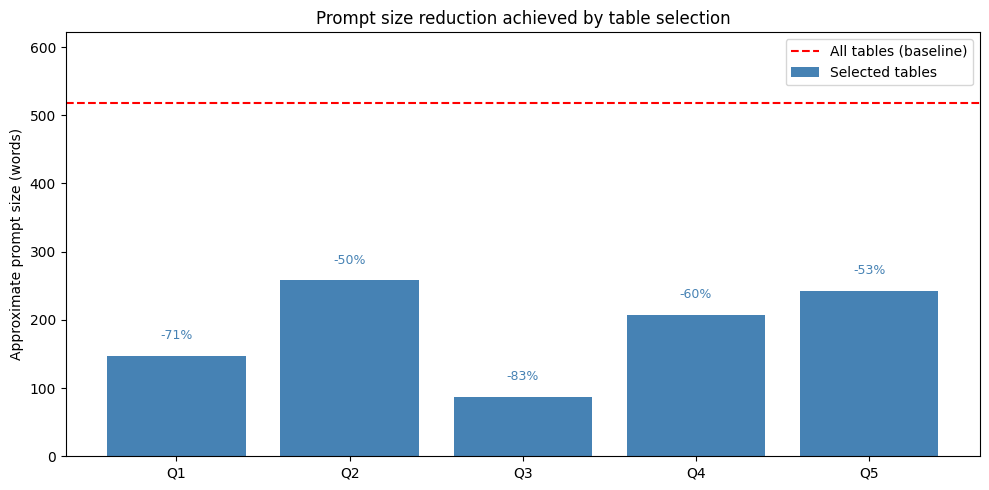

Full schema prompt : ~518 words
Average selected   : ~188 words
Average reduction  : ~64%


In [18]:
import matplotlib.pyplot as plt

full_schema_size = len(build_sql_prompt('', list(SCHEMAS.keys())).split())

questions_short = ['Q{}'.format(i + 1) for i in range(len(results))]
selected_sizes  = [
    len(build_sql_prompt(r['question'], r['tables']).split())
    for r in results
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(questions_short, selected_sizes, color='steelblue', label='Selected tables')
ax.axhline(full_schema_size, color='red', linestyle='--', linewidth=1.5, label='All tables (baseline)')

for bar, sz in zip(bars, selected_sizes):
    pct = int((1 - sz / full_schema_size) * 100)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            '-{}%'.format(pct), ha='center', va='bottom', fontsize=9, color='steelblue')

ax.set_ylabel('Approximate prompt size (words)')
ax.set_title('Prompt size reduction achieved by table selection')
ax.legend()
ax.set_ylim(0, full_schema_size * 1.2)
plt.tight_layout()
plt.savefig('prompt_size_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

print('Full schema prompt : ~{} words'.format(full_schema_size))
print('Average selected   : ~{} words'.format(int(sum(selected_sizes) / len(selected_sizes))))
print('Average reduction  : ~{:.0f}%'.format(
    (1 - sum(selected_sizes) / len(selected_sizes) / full_schema_size) * 100
))

## Summary

Stage 2 takes the table list from Stage 1 and builds a focused, schema-rich prompt that
produces accurate SQL without paying the cost of the full database schema on every call.

**Next step →** [E1_3_NL2SQL_Pipeline.ipynb](E1_3_NL2SQL_Pipeline.ipynb) wires both stages
into the final `obtainSQL()` API with automatic model selection.